<a href="https://colab.research.google.com/github/Veritax0/clasificacion-imagenes-redes-neuronales/blob/main/notebooks/02_mejoras_Data_Augmentation_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación Bart vs Homero — Mejoras: Data Augmentation + Transfer Learning + Grad-CAM

**Proyecto Deep Learning**  
Dataset: [Homer & Bart Classification (Kaggle)](https://www.kaggle.com/datasets/juniorbueno/neural-networks-homer-and-bart-classification/)

Este notebook mejora la CNN baseline del `01_baseline_cnn.ipynb` con:
- **Data Augmentation** integrado en el pipeline de Keras (solo transformaciones geométricas)
- **Transfer Learning con MobileNetV2** (preentrenado en ImageNet)
- **Fine-tuning parcial** (últimas ~54 capas del backbone)
- **Batch size reducido** (16) para más pasos de gradiente con dataset pequeño
- **Grad-CAM** para visualizar qué regiones activa el modelo
- **Early Stopping** y **Regularización L2**

> **Estructura del dataset:** todas las imágenes `.bmp` están en una sola carpeta, etiquetadas por nombre de archivo (e.g. `bart_001.bmp`, `homer_042.bmp`).

## 0. Instalación

In [91]:
# !pip install tensorflow matplotlib scikit-learn seaborn

## 1. Descarga del Dataset desde Kaggle

Necesitas un archivo `kaggle.json` con tus credenciales de API.  
Puedes generarlo en [kaggle.com → Settings → API → Create New Token](https://www.kaggle.com/settings).

**En Google Colab**, sube el archivo cuando se pida y ejecuta todas las celdas.

In [92]:
import os

DATASET_DIR = "data"

if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR, exist_ok=True)
    os.system(
        'kaggle datasets download '
        '-d juniorbueno/neural-networks-homer-and-bart-classification '
        f'--unzip -p {DATASET_DIR}'
    )
    print('Dataset descargado y descomprimido.')
else:
    print('Dataset ya existe, se omite la descarga.')

archivos = [f for f in os.listdir(DATASET_DIR + "/homer_bart_1") if f.lower().endswith('.bmp')]
print(f'Total de imágenes .bmp encontradas: {len(archivos)}')
print('Primeros 10 archivos:', archivos[:10])

Dataset ya existe, se omite la descarga.
Total de imágenes .bmp encontradas: 269
Primeros 10 archivos: ['bart81.bmp', 'bart108.bmp', 'bart74.bmp', 'homer52.bmp', 'homer57.bmp', 'bart114.bmp', 'bart15.bmp', 'bart13.bmp', 'bart113.bmp', 'bart73.bmp']


## 2. Imports y configuración

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve, auc
)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs disponibles: {gpus if gpus else 'Ninguna (usando CPU)'}")

# ── Hiperparámetros ─────────────────────────────────────────────────────────
# MobileNetV2 requiere mínimo 96x96; 160 es buen balance velocidad/calidad
IMG_SIZE        = 160
BATCH_SIZE      = 8  # Reducido de 32: más pasos de gradiente por época con dataset pequeño
EPOCHS_FROZEN   = 15
EPOCHS_FINETUNE = 25
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-4
PATIENCE        = 10
VAL_SPLIT       = 0.15
TEST_SPLIT      = 0.15
CLASS_NAMES     = ['bart', 'homer']

print(f"Imagen: {IMG_SIZE}x{IMG_SIZE} | Batch: {BATCH_SIZE}")
print(f"Fases: {EPOCHS_FROZEN} épocas frozen + {EPOCHS_FINETUNE} fine-tuning")

TensorFlow: 2.20.0
GPUs disponibles: Ninguna (usando CPU)
Imagen: 160x160 | Batch: 8
Fases: 15 épocas frozen + 25 fine-tuning


## 3. Carga del dataset desde carpeta plana

In [94]:
def extraer_etiqueta(nombre_archivo):
    nombre = nombre_archivo.lower()
    if 'bart' in nombre:
        return 0
    elif 'homer' in nombre:
        return 1
    return None


def cargar_dataset(directorio, img_size):
    rutas, etiquetas = [], []

    for archivo in sorted(os.listdir(directorio)):
        if not archivo.lower().endswith('.bmp'):
            continue
        etiqueta = extraer_etiqueta(archivo)
        if etiqueta is None:
            continue
        rutas.append(os.path.join(directorio, archivo))
        etiquetas.append(etiqueta)

    print(f"Leyendo {len(rutas)} imágenes...")
    X = np.zeros((len(rutas), img_size, img_size, 3), dtype=np.float32)
    for i, ruta in enumerate(rutas):
        raw = tf.io.read_file(ruta)
        img = tf.image.decode_bmp(raw, channels=3)
        img = tf.image.resize(img, [img_size, img_size])
        X[i] = img.numpy()

    return X, np.array(etiquetas, dtype=np.int32)


X, y = cargar_dataset(DATASET_DIR + "/homer_bart_1", IMG_SIZE)

# Normalización para MobileNetV2: escala [-1, 1]
X = X / 127.5 - 1.0

print(f"Dataset: {X.shape} | Bart: {(y==0).sum()} | Homer: {(y==1).sum()}")

# Split estratificado
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)
val_frac = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_frac, random_state=SEED, stratify=y_trainval
)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Leyendo 269 imágenes...
Dataset: (269, 160, 160, 3) | Bart: 160 | Homer: 109
Train: 187 | Val: 41 | Test: 41


## 4. Data Augmentation

Se define como un bloque de capas Keras que se aplica **solo durante el entrenamiento** (`training=True`). En validación y test las capas `Random*` se comportan como identidad automáticamente.

In [95]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomFlip('vertical'),
    layers.RandomRotation(0.15),           # ±15% de rotación
    layers.RandomZoom(0.15),               # ±15% zoom
    layers.RandomTranslation(0.1, 0.1),    # ±10% desplazamiento
    # RandomBrightness / RandomContrast eliminados: personajes 2D con colores
    # planos — variaciones de color mínimas arruinan la imagen
], name='data_augmentation')

print("Bloque de augmentation definido.")

Bloque de augmentation definido.


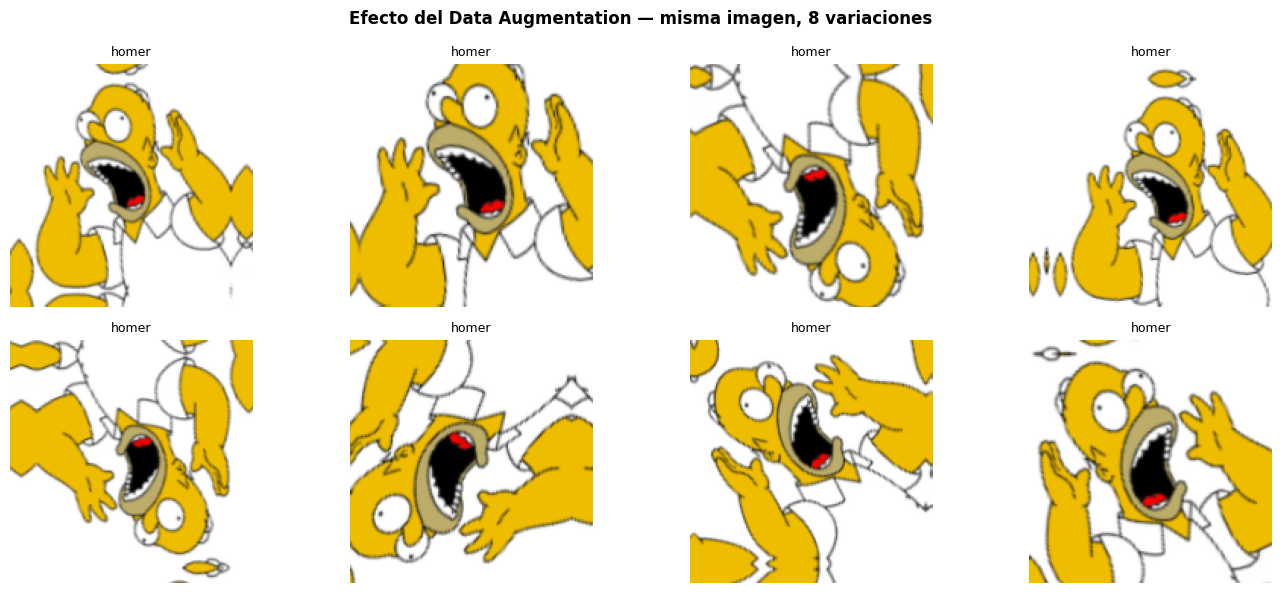

In [96]:
# ── Visualizar efecto del augmentation ──────────────────────────────────────
def desnormalizar(img):
    """Convierte de [-1,1] a [0,1] para visualización."""
    return np.clip((img + 1.0) / 2.0, 0, 1)

muestra = X_train[0:2]  # (1, H, W, 3)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax in axes.flat:
    aug = data_augmentation(muestra, training=True)[0].numpy()
    ax.imshow(desnormalizar(aug))
    ax.set_title(CLASS_NAMES[y_train[0]], fontsize=9)
    ax.axis('off')

plt.suptitle('Efecto del Data Augmentation — misma imagen, 8 variaciones',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Modelo: Transfer Learning con MobileNetV2

**Estrategia en dos fases:**
1. **Fase 1 — Backbone congelado:** solo se entrena el nuevo clasificador. Rápido y estable.
2. **Fase 2 — Fine-tuning:** se descongela todo el backbone con LR muy pequeño para adaptar los features al dominio de los Simpsons.

In [97]:
def construir_modelo_transfer(img_size, num_classes=2, freeze_backbone=True):
    inputs = keras.Input(shape=(img_size, img_size, 3), name='imagen')

    # Augmentation (activo solo durante training)
    x = data_augmentation(inputs)

    # Backbone preentrenado
    base_model = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = not freeze_backbone

    # training=False para que BatchNorm del backbone use estadísticas de inferencia
    x = base_model(x, training=False)

    # Nuevo clasificador — una sola capa densa: el backbone ya genera
    # embeddings ricos; menos parámetros = menos sobreajuste con ~190 muestras
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='prediccion')(x)

    return keras.Model(inputs, outputs, name='MobileNetV2_TL'), base_model


model, base_model = construir_modelo_transfer(IMG_SIZE, freeze_backbone=True)
model.summary()

total   = model.count_params()
entrena = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"\nParámetros totales:           {total:,}")
print(f"Parámetros entrenables (head): {entrena:,}")

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediccion (Dense)              │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Parámetros totales:           2,422,210
Parámetros entrenables (head): 164,226


## 6. Fase 1 — Entrenar solo el clasificador (backbone congelado)

In [98]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase1 = [
    keras.callbacks.ModelCheckpoint(
        'mobilenet_fase1.keras', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, verbose=1, min_lr=1e-6
    ),
]

print('=' * 55)
print('  FASE 1 — Backbone congelado, solo clasificador')
print('=' * 55)

historia_f1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FROZEN,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_fase1,
    verbose=1
)

  FASE 1 — Backbone congelado, solo clasificador
Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.5915 - loss: 1.1055
Epoch 1: val_loss improved from None to 0.74326, saving model to mobilenet_fase1.keras

Epoch 1: finished saving model to mobilenet_fase1.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 350ms/step - accuracy: 0.6631 - loss: 0.8737 - val_accuracy: 0.5610 - val_loss: 0.7433 - learning_rate: 0.0010
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7644 - loss: 0.5894
Epoch 2: val_loss improved from 0.74326 to 0.60065, saving model to mobilenet_fase1.keras

Epoch 2: finished saving model to mobilenet_fase1.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - accuracy: 0.7647 - loss: 0.5710 - val_accuracy: 0.6829 - val_loss: 0.6006 - learning_rate: 0.0010
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8030 - loss: 0.4314
Epoch 3: val_loss improved from 0.60065 to 0.58313, saving model to mobilenet_fase1.keras

Epoch 3: finished saving mod

## 7. Fase 2 — Fine-tuning: descongelar el backbone

In [99]:
# Fine-tuning PARCIAL: solo las últimas N capas del backbone
# Descongelar todo primero, luego recongelar las capas iniciales
base_model.trainable = True

FINE_TUNE_AT = 100  # MobileNetV2 tiene 154 capas; descongelamos las últimas 54
               # Las primeras capas detectan bordes/texturas genéricas
               # Las últimas capas detectan patrones de alto nivel
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

entrena_ft = sum(tf.size(v).numpy() for v in model.trainable_variables)
total_ft   = model.count_params()
print(f"Parámetros totales:                      {total_ft:,}")
print(f"Parámetros entrenables (fine-tuning parcial): {entrena_ft:,}")
print(f"Capas congeladas: {FINE_TUNE_AT} | Capas libres: {len(base_model.layers) - FINE_TUNE_AT}")

# Recompilar con LR muy pequeño para no destruir los features aprendidos
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase2 = [
    keras.callbacks.ModelCheckpoint(
        'mobilenet_fase2_best.keras', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, verbose=1, min_lr=1e-7
    ),
]

print('=' * 55)
print('  FASE 2 — Fine-tuning parcial del backbone')
print('=' * 55)

historia_f2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FINETUNE,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_fase2,
    verbose=1
)

Parámetros totales:                      2,422,210
Parámetros entrenables (fine-tuning parcial): 2,025,666
Capas congeladas: 100 | Capas libres: 54
  FASE 2 — Fine-tuning parcial del backbone
Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7832 - loss: 0.4658
Epoch 1: val_loss improved from None to 0.54373, saving model to mobilenet_fase2_best.keras

Epoch 1: finished saving model to mobilenet_fase2_best.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 541ms/step - accuracy: 0.7647 - loss: 0.4641 - val_accuracy: 0.8780 - val_loss: 0.5437 - learning_rate: 1.0000e-04
Epoch 2/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8660 - loss: 0.2929
Epoch 2: val_loss did not improve from 0.54373
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 406ms/step - accuracy: 0.8770 - loss: 0.2946 - val_accuracy: 0.8293 - val_loss: 0.5880 - learning_rate: 1.0000e-04
Epoch 3/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8731 - loss: 0.3065
Epoch 3: val_loss improved from 0.54373 to 0.52633, savin

## 8. Curvas de aprendizaje (ambas fases)

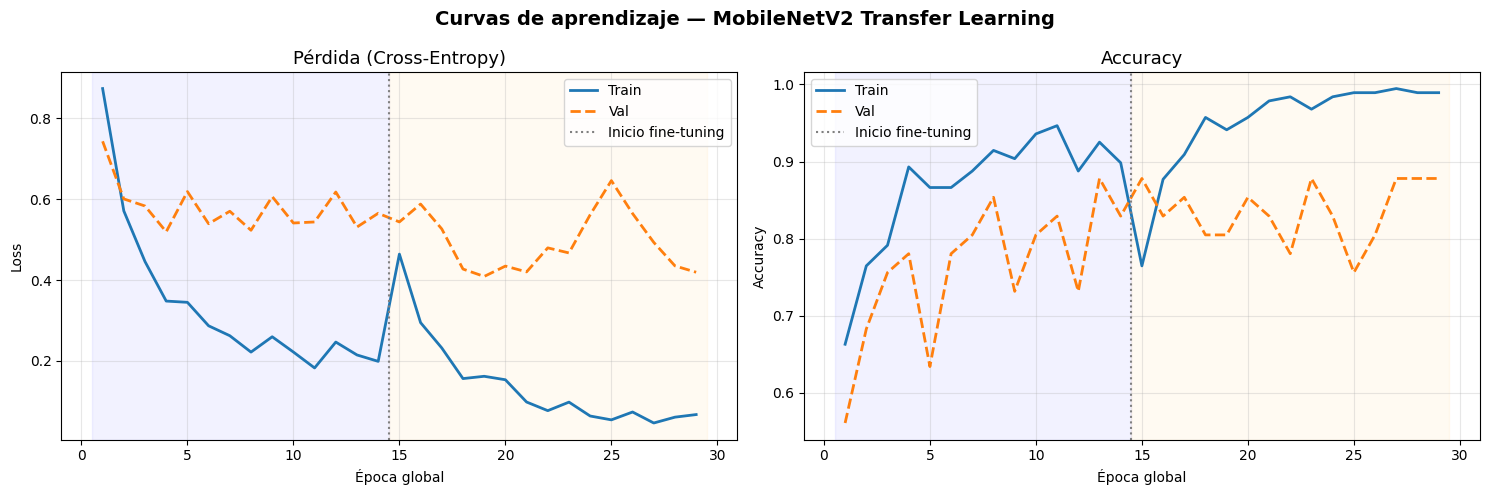

In [100]:
def concatenar_historias(h1, h2):
    resultado = {}
    for clave in h1.history:
        resultado[clave] = h1.history[clave] + h2.history.get(clave, [])
    return resultado


hist = concatenar_historias(historia_f1, historia_f2)
n1   = len(historia_f1.history['loss'])
n2   = len(historia_f2.history['loss'])
epocas_totales = range(1, n1 + n2 + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for ax, tk, vk, title, ylabel in [
    (ax1, 'loss', 'val_loss', 'Pérdida (Cross-Entropy)', 'Loss'),
    (ax2, 'accuracy', 'val_accuracy', 'Accuracy', 'Accuracy'),
]:
    ax.plot(epocas_totales, hist[tk], label='Train', linewidth=2)
    ax.plot(epocas_totales, hist[vk], label='Val',   linewidth=2, linestyle='--')
    ax.axvline(n1 + 0.5, color='gray', linestyle=':', linewidth=1.5, label='Inicio fine-tuning')
    ax.axvspan(0.5,       n1 + 0.5,       alpha=0.05, color='blue')
    ax.axvspan(n1 + 0.5,  n1 + n2 + 0.5,  alpha=0.05, color='orange')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Época global'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje — MobileNetV2 Transfer Learning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluación en el conjunto de test

In [101]:
mejor_modelo = keras.models.load_model('mobilenet_fase2_best.keras')
probs_test   = mejor_modelo.predict(X_test, batch_size=BATCH_SIZE)
y_pred       = np.argmax(probs_test, axis=1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print('=' * 52)
print('  MÉTRICAS EN TEST — MobileNetV2 Transfer Learning')
print('=' * 52)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 52)
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 520ms/step
  MÉTRICAS EN TEST — MobileNetV2 Transfer Learning
  Accuracy  : 0.9024  (90.24%)
  Precision : 0.9079
  Recall    : 0.9024
  F1-Score  : 0.9030

              precision    recall  f1-score   support

        bart       0.95      0.88      0.91        24
       homer       0.84      0.94      0.89        17

    accuracy                           0.90        41
   macro avg       0.90      0.91      0.90        41
weighted avg       0.91      0.90      0.90        41



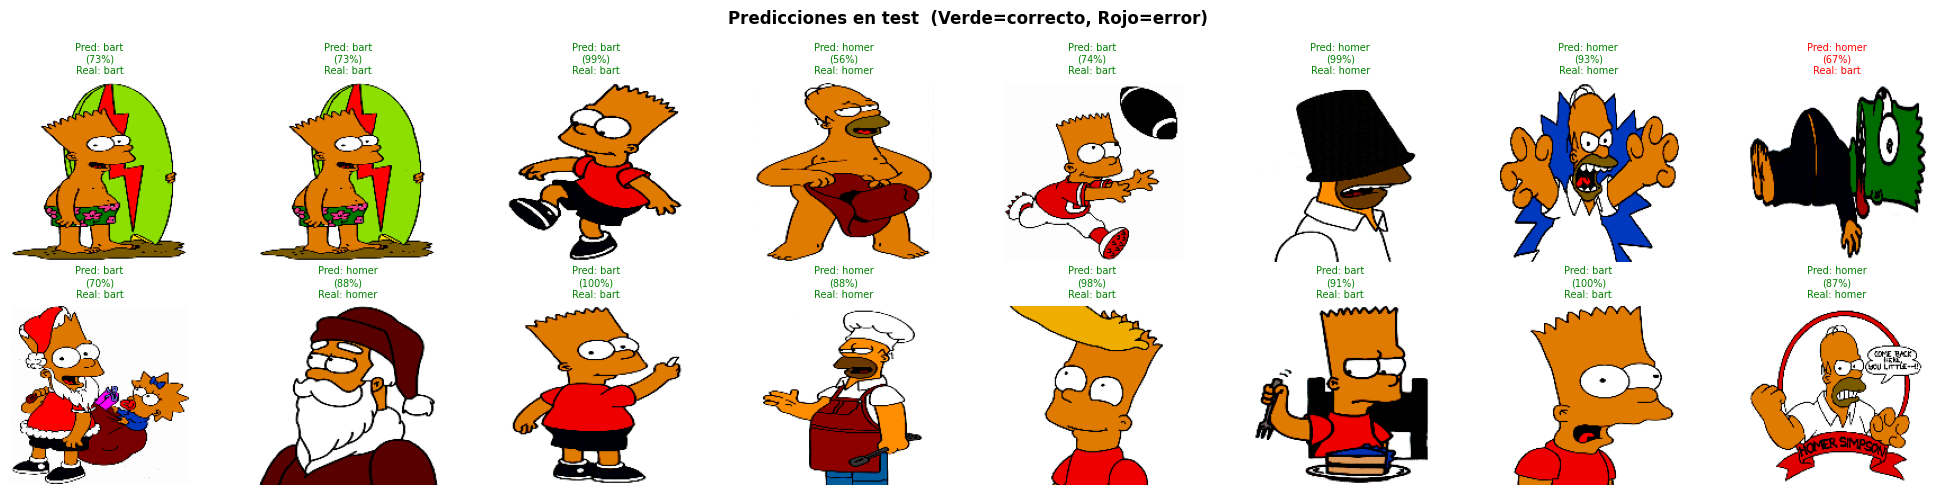

In [102]:
n_show  = 16
indices = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for i, ax in enumerate(axes.flat):
    idx      = indices[i]
    pred_cls = CLASS_NAMES[y_pred[idx]]
    true_cls = CLASS_NAMES[y_test[idx]]
    conf     = probs_test[idx][y_pred[idx]]
    color    = 'green' if pred_cls == true_cls else 'red'

    ax.imshow(X_test[idx])
    ax.set_title(f'Pred: {pred_cls}\n({conf:.0%})\nReal: {true_cls}',
                 color=color, fontsize=7)
    ax.axis('off')

plt.suptitle('Predicciones en test  (Verde=correcto, Rojo=error)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('predicciones_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

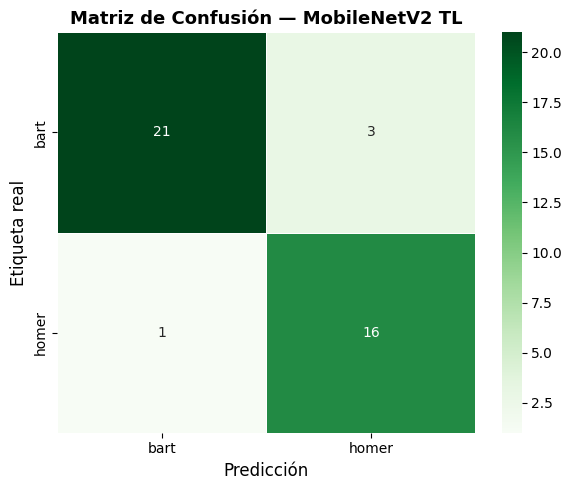

In [103]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Etiqueta real', fontsize=12)
ax.set_title('Matriz de Confusión — MobileNetV2 TL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Curva ROC

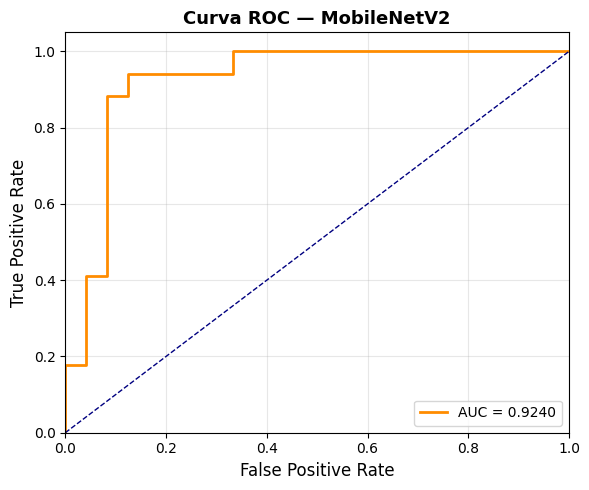

AUC: 0.9240


In [104]:
fpr, tpr, _ = roc_curve(y_test, probs_test[:, 1])
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curva ROC — MobileNetV2', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC: {roc_auc:.4f}')

## 11. Grad-CAM — ¿Qué está mirando el modelo?

Grad-CAM (*Gradient-weighted Class Activation Mapping*) calcula el gradiente de la clase predicha respecto al último mapa de activación convolucional y lo proyecta sobre la imagen original. Zonas cálidas (rojo/amarillo) indican qué regiones influyen más en la decisión del modelo.

Esto permite verificar si el modelo clasifica por el **personaje** o por **artefactos del fondo**.

In [105]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Construcción del modelo Grad-CAM ────────────────────────────────────────
# El problema de apuntar a una capa interna del backbone desde la entrada del
# modelo completo es que Keras no puede trazar el grafo: hay capas intermedias
# (augmentation, preprocesamiento) entre la entrada y el backbone.
#
# Solución: construir grad_model DENTRO del backbone, pasando directamente
# las imágenes ya preprocesadas (normalizadas a [-1,1]) como entrada.
modelo_gradcam = keras.models.load_model('mobilenet_fase2_best.keras')

# Extraer el backbone (submodelo MobileNetV2)
backbone = modelo_gradcam.get_layer('mobilenetv2_1.00_160')

# Última capa conv del backbone antes del GlobalAveragePooling
ultimo_conv_layer = backbone.get_layer('out_relu')

# grad_model: entrada del backbone → [mapa de activación, salida del backbone]
grad_model = tf.keras.Model(
    inputs  = backbone.input,
    outputs = [ultimo_conv_layer.output, backbone.output]
)

capas_post_backbone = []
encontrado = False
for layer in modelo_gradcam.layers:
    if encontrado:
        capas_post_backbone.append(layer)
    if layer.name == 'mobilenetv2_1.00_160':
        encontrado = True

def hacer_gradcam(img_array, clase_idx=None):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, backbone_out = grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)

        x = backbone_out
        for layer in capas_post_backbone:
            x = layer(x, training=False)
        predictions = x

        if clase_idx is None:
            clase_idx = int(tf.argmax(predictions[0]))
        loss = predictions[:, clase_idx]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_map     = conv_outputs[0]
    heatmap      = conv_map @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.nn.relu(heatmap)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def superponer_gradcam(img_norm, heatmap, alpha=0.4):
    img_vis = np.clip((img_norm + 1.0) / 2.0, 0, 1)
    h, w    = img_vis.shape[:2]
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], [h, w]
    ).numpy().squeeze()
    colormap    = cm.get_cmap('jet')
    heatmap_rgb = colormap(heatmap_resized)[:, :, :3]
    superposed  = (1 - alpha) * img_vis + alpha * heatmap_rgb
    return np.clip(superposed, 0, 1)


print('Funciones Grad-CAM definidas correctamente.')
print(f'Capas post-backbone: {[l.name for l in capas_post_backbone]}')

Funciones Grad-CAM definidas correctamente.
Capas post-backbone: ['global_average_pooling2d_5', 'dense_5', 'dropout_5', 'prediccion']


/tmp/ipykernel_10209/200129310.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap    = cm.get_cmap('jet')


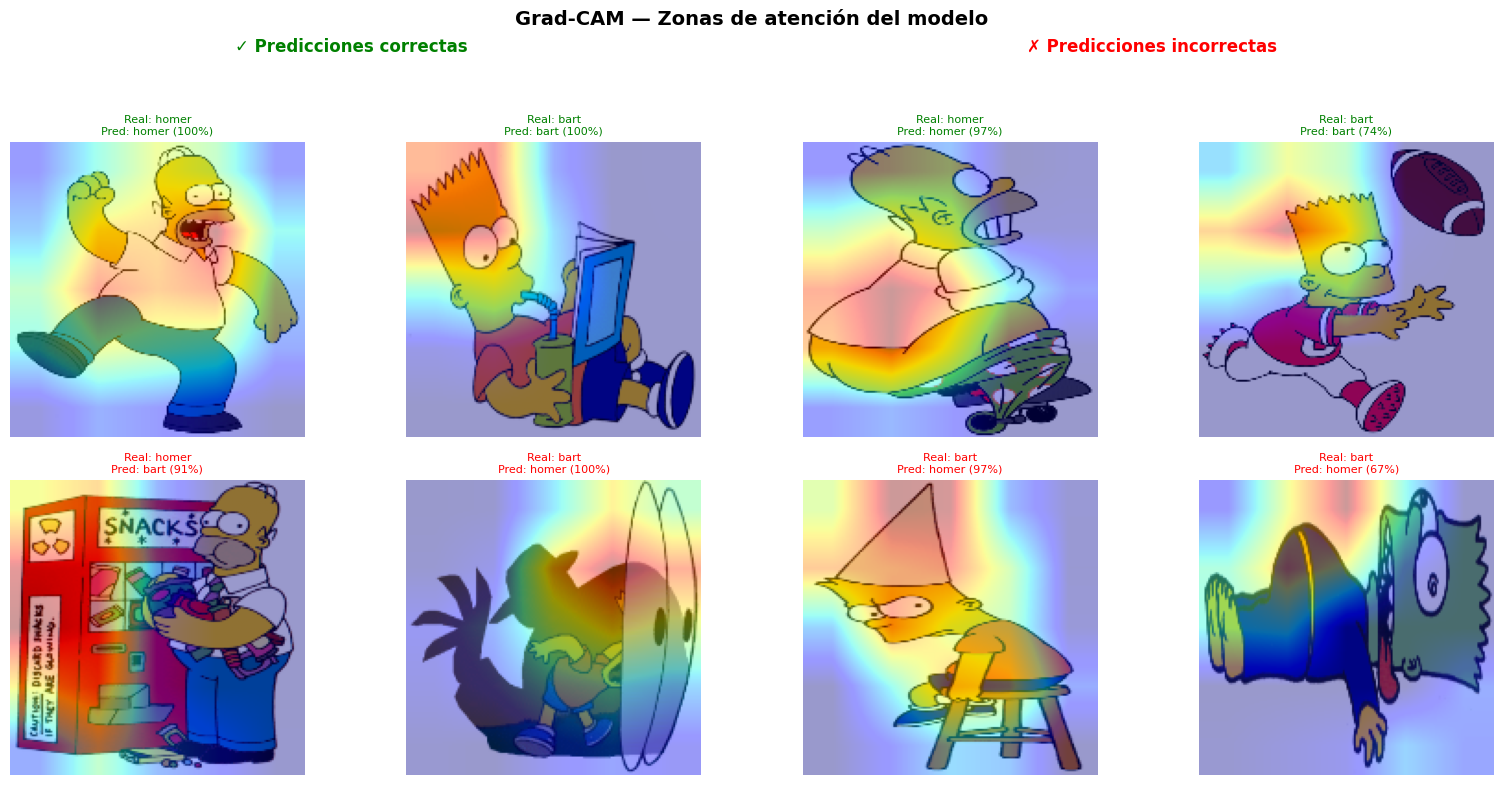


Muestras visualizadas: 4 correctas, 4 incorrectas


In [106]:
# ── Visualización Grad-CAM: 8 muestras del test ──────────────────────────────
# 4 correctas + 4 incorrectas para contrastar qué aprende el modelo
probs_gc = modelo_gradcam.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred_gc = np.argmax(probs_gc, axis=1)

correctos   = np.where(y_pred_gc == y_test)[0]
incorrectos = np.where(y_pred_gc != y_test)[0]

# Seleccionar hasta 4 de cada grupo (pueden ser menos si el modelo acierta todo)
n_cada = 4
idx_c = correctos[:n_cada]
idx_e = incorrectos[:n_cada]
indices_gc = np.concatenate([idx_c, idx_e])

n_cols = 4
n_rows = 2 * int(np.ceil(len(indices_gc) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

ax_idx = 0
for grupo, indices, titulo_grupo in [
    ('✓ Correctas', idx_c, 'green'),
    ('✗ Incorrectas', idx_e, 'red')
]:
    for idx in indices:
        img   = X_test[idx]                         # (H, W, 3) normalizado [-1,1]
        label = y_test[idx]
        pred  = y_pred_gc[idx]
        conf  = probs_gc[idx][pred]

        heatmap   = hacer_gradcam(img[np.newaxis, ...], clase_idx=pred)
        img_super = superponer_gradcam(img, heatmap)

        ax = axes[ax_idx]
        ax.imshow(img_super)
        color = 'green' if pred == label else 'red'
        ax.set_title(
            f"Real: {CLASS_NAMES[label]}\nPred: {CLASS_NAMES[pred]} ({conf:.0%})",
            color=color, fontsize=8
        )
        ax.axis('off')
        ax_idx += 1

# Ocultar ejes sobrantes
for ax in axes[ax_idx:]:
    ax.set_visible(False)

fig.text(0.25, 1.01, '✓ Predicciones correctas', ha='center',
         fontsize=12, color='green', fontweight='bold')
fig.text(0.75, 1.01, '✗ Predicciones incorrectas', ha='center',
         fontsize=12, color='red', fontweight='bold')

plt.suptitle('Grad-CAM — Zonas de atención del modelo',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('gradcam_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMuestras visualizadas: {len(idx_c)} correctas, {len(idx_e)} incorrectas")
if len(idx_e) == 0:
    print("El modelo clasificó correctamente todos los ejemplos de test.")


## 11. Comparación con el baseline

                Accuracy  Precision  Recall  F1-Score
Modelo                                               
CNN Baseline      0.6341     0.6376  0.6341    0.6355
MobileNetV2 TL    0.9024     0.9079  0.9024    0.9030


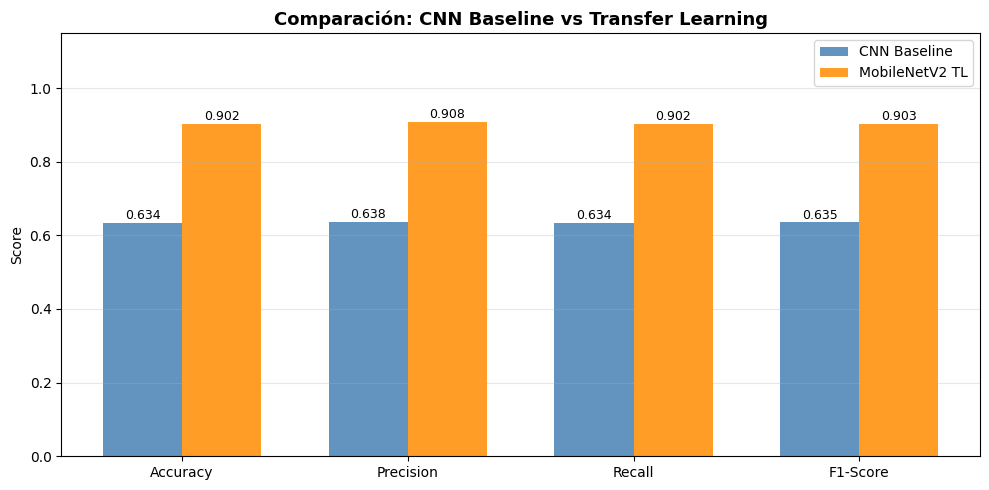

In [107]:
import pandas as pd

# Reemplaza los 0.0 del baseline con los valores reales del notebook 01
resultados = {
    'Modelo':    ['CNN Baseline', 'MobileNetV2 TL'],
    'Accuracy':  [0.6341,  acc],
    'Precision': [0.6376, prec],
    'Recall':    [0.6341,  rec],
    'F1-Score':  [0.6355,   f1],
}

df = pd.DataFrame(resultados).set_index('Modelo')
print(df.round(4).to_string())

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x     = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - ancho/2, df.loc['CNN Baseline'],   ancho, label='CNN Baseline',   color='steelblue',  alpha=0.85)
b2 = ax.bar(x + ancho/2, df.loc['MobileNetV2 TL'], ancho, label='MobileNetV2 TL', color='darkorange', alpha=0.85)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Comparación: CNN Baseline vs Transfer Learning',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Conclusiones

### Técnicas aplicadas

| Técnica | Objetivo |
|---|---|
| Data Augmentation (flip, rotate, zoom, traslación) | Reduce sobreajuste con dataset pequeño; brillo/contraste eliminados (colores planos 2D) |
| Transfer Learning (MobileNetV2 ImageNet) | Features preaprendidas de 1.2M imágenes |
| Fine-tuning parcial (últimas 54 capas) | Adapta features de alto nivel sin destruir representaciones genéricas |
| Regularización L2 en capas densas | Penaliza pesos grandes |
| Early Stopping | Evita sobreentrenar |
| ReduceLROnPlateau | Ajusta el LR cuando el entrenamiento se estanca |

### Resultados

| Métrica | CNN Baseline | MobileNetV2 |
|---|---|---|
| Accuracy | 0.6341 | 0.9024 |
| F1-Score | 0.6355 | 0.9030 |

### Posibles mejoras adicionales
- **EfficientNetB0 / B3**: mejor trade-off accuracy/parámetros
- **Mixup / CutMix**: augmentation a nivel de batch
- **CrossValidation**: variar el conjunto de validación